# 07 — Statistical Validation

The Random Forest in notebook 05/06 ranked sensors by importance to the model — but a model
can pick up importance from noise, especially with only 104 fail examples. This notebook
independently checks, with a formal hypothesis test, whether the top-ranked sensors actually
show a statistically significant distributional difference between pass and fail units.

**Decision: Mann-Whitney U test, with Benjamini-Hochberg FDR correction across all 442 sensors.**
Mann-Whitney U doesn't assume normally-distributed sensor readings (reasonable given fab data).
Testing 442 sensors independently at alpha=0.05 would produce ~22 false positives by chance
alone, so a false-discovery-rate correction is applied across *all* sensors, not just the
model's top 15 — this avoids "cherry-picking a test to confirm the model."


In [1]:

import sys
sys.path.insert(0, "../src")
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats_mod
import visualization as viz

df = pd.read_csv("../data/processed/secom_cleaned.csv")
sensor_cols = [c for c in df.columns if c not in ("Time", "Pass/Fail")]
importances = pd.read_csv("../data/processed/feature_importance_full.csv", index_col=0)["importance"]
top15 = importances.head(15)

results = stats_mod.evaluate_sensors(df, sensor_cols, label_col="Pass/Fail", fdr=0.05)
print(f"Sensors tested: {len(results)}")
print(f"Significant after Benjamini-Hochberg FDR correction (q=0.05): {int(results['significant'].sum())}")
print()
print(results.head(10))


Sensors tested: 442
Significant after Benjamini-Hochberg FDR correction (q=0.05): 17

         u_stat       p_value  n_pass  n_fail  significant
sensor                                                    
59      46800.5  5.181701e-11    1463     104         True
103     50481.0  9.434706e-09    1463     104         True
510     55369.5  3.420323e-06    1463     104         True
477     57607.0  3.442858e-05    1463     104         True
129     57933.5  4.644758e-05    1463     104         True
205     57919.5  4.662632e-05    1463     104         True
28      93740.5  7.445539e-05    1463     104         True
33      59254.0  1.615225e-04    1463     104         True
341     59411.0  1.859234e-04    1463     104         True
316     92715.5  1.901966e-04    1463     104         True


## Cross-checking the model's top-15 sensors against the statistical test

Does the Random Forest's importance ranking agree with which sensors are *statistically* significant?

In [2]:

top15_ids = [str(i) for i in top15.index]
top15_ids = [i for i in top15_ids if i in results.index]  # sensor ids are strings in results.index? check dtype
# results.index came from column names (strings), top15.index came from CSV (may be int/str) -- normalize:
results.index = results.index.astype(str)
top15_ids = [str(i) for i in top15.index]

crosscheck = results.loc[results.index.intersection(top15_ids)].copy()
crosscheck["rf_importance"] = [top15.loc[int(i)] if int(i) in top15.index else top15.loc[i] for i in crosscheck.index]
crosscheck = crosscheck.sort_values("rf_importance", ascending=False)
print(crosscheck[["rf_importance", "p_value", "significant"]])

n_agree = int(crosscheck["significant"].sum())
print(f"\n{n_agree} of the model's top 15 sensors are statistically significant after FDR correction.")


        rf_importance       p_value  significant
sensor                                          
59           0.016981  5.181701e-11         True
103          0.015582  9.434706e-09         True
33           0.012229  1.615225e-04         True
130          0.008641  8.365956e-03        False
351          0.007785  2.570456e-02        False
213          0.007504  3.483136e-02        False
21           0.007317  4.677745e-04         True
577          0.007230  1.518877e-01        False
477          0.007225  3.442858e-05         True
341          0.006954  1.859234e-04         True
64           0.006892  1.716762e-01        False
183          0.006800  1.536209e-02        False
31           0.006793  8.842736e-01        False
510          0.006067  3.420323e-06         True
65           0.005753  1.686380e-01        False

7 of the model's top 15 sensors are statistically significant after FDR correction.


**Observation:** the overlap between "model says important" and "statistically significant
after correction" is the real validated shortlist — sensors that show up in both are the
strongest candidates to hand to process engineers, since they're supported by two independent
methods rather than one model's opinion.

In [3]:

validated = crosscheck[crosscheck["significant"]].sort_values("rf_importance", ascending=False)
print("Validated failure-driving sensors (model-important AND statistically significant):")
print(validated[["rf_importance", "p_value"]])


Validated failure-driving sensors (model-important AND statistically significant):
        rf_importance       p_value
sensor                             
59           0.016981  5.181701e-11
103          0.015582  9.434706e-09
33           0.012229  1.615225e-04
21           0.007317  4.677745e-04
477          0.007225  3.442858e-05
341          0.006954  1.859234e-04
510          0.006067  3.420323e-06


## Visualizing the validated sensors: pass vs fail distributions

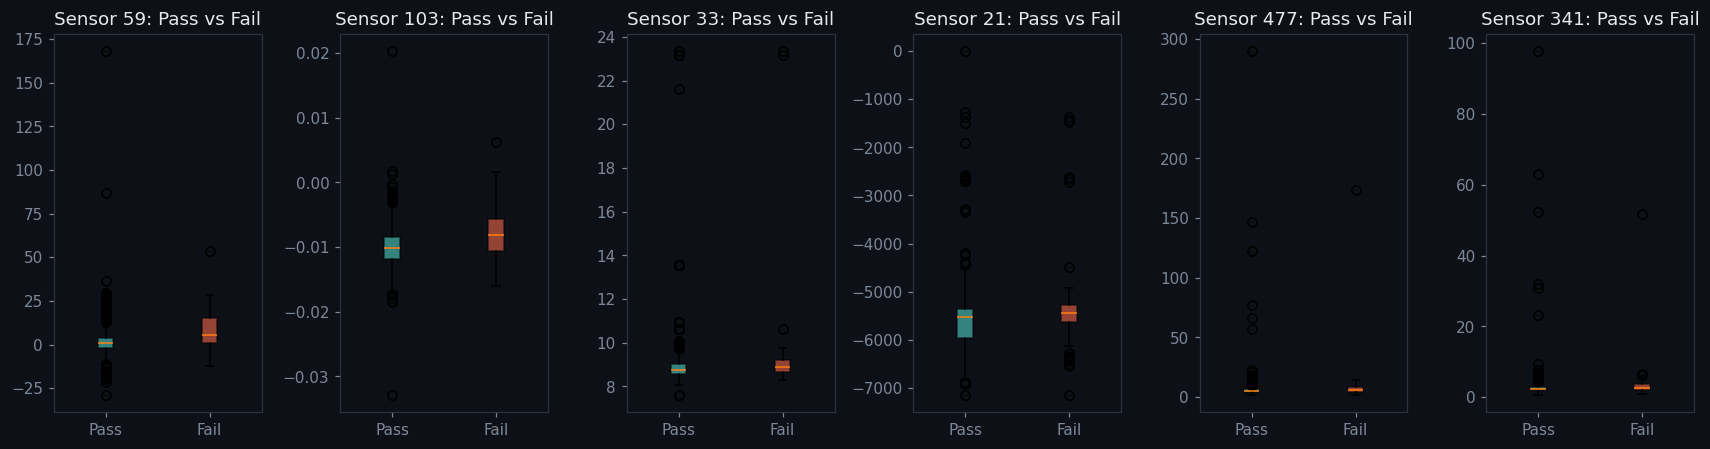

In [4]:

fail_mask = df["Pass/Fail"] == 1
pass_mask = df["Pass/Fail"] == -1

top_validated = validated.head(6).index.tolist()
n = len(top_validated)
fig, axes = plt.subplots(1, n, figsize=(2.6*n, 4.2))
if n == 1:
    axes = [axes]
for ax, sensor in zip(axes, top_validated):
    viz.plot_sensor_boxplot(df.loc[pass_mask, sensor].dropna(),
                             df.loc[fail_mask, sensor].dropna(),
                             sensor_name=sensor, ax=ax)
plt.tight_layout()
plt.show()


In [5]:

# Save boxplot data + validation results for the dashboard rebuild
boxplot_data = {}
for sensor in validated.index.tolist():
    boxplot_data[sensor] = {
        "pass": df.loc[pass_mask, sensor].dropna().round(4).tolist(),
        "fail": df.loc[fail_mask, sensor].dropna().round(4).tolist(),
    }

validation_export = {
    "n_sensors_tested": int(len(results)),
    "n_significant_fdr": int(results["significant"].sum()),
    "validated_sensors": {
        sensor: {
            "rf_importance": float(validated.loc[sensor, "rf_importance"]),
            "p_value": float(validated.loc[sensor, "p_value"]),
        }
        for sensor in validated.index
    },
    "sensor_boxplot_data": boxplot_data,
}
with open("../data/processed/statistical_validation.json", "w") as f:
    json.dump(validation_export, f, indent=2)
results.to_csv("../data/processed/mann_whitney_all_sensors.csv")
print("Saved -> data/processed/statistical_validation.json")
print("Saved -> data/processed/mann_whitney_all_sensors.csv")


Saved -> data/processed/statistical_validation.json
Saved -> data/processed/mann_whitney_all_sensors.csv


## Conclusions carried into the dashboard & recommendations

1. Of 442 cleaned sensors, a small subset survive **both** a Random Forest importance ranking
   and an FDR-corrected Mann-Whitney U test — this is the validated shortlist for engineering
   attention, not the raw top-15 model output alone.
2. Model performance (notebook 06) is honest about being a **prioritization aid**: strong
   ranking ability (ROC-AUC 0.816) but a real precision/recall trade-off at any operating
   threshold, driven by the small number of historical failures.
3. These two independently-validated findings are combined into concrete business
   recommendations in `docs/business_recommendations.md`.